In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

In [4]:
df = pd.read_csv(r"C:\Users\ssham\Downloads\intern_performance_cleaned.csv")
print(df.shape)
print(df['performance_label'].value_counts())
print(df.head())

(1000, 5)
performance_label
High      340
Low       330
Medium    330
Name: count, dtype: int64
  Intern_ID  Completion_Time  Feedback_Rating  Attendance performance_label
0   INT0001         3.260000         4.090000       86.50              High
1   INT0002         3.928256         1.330000       59.23               Low
2   INT0003         5.780000         2.933667       42.98               Low
3   INT0004         4.280000         1.430000       83.16               Low
4   INT0005         1.530000         1.910000       74.10            Medium


In [5]:
df['Performance_Index'] = df['Feedback_Rating'] * df['Attendance'] / 100
df['Completion_Speed'] = 1 / df['Completion_Time']
df['Attendance_Category'] = pd.cut(
    df['Attendance'],
    bins=[0, 60, 80, 100],
    labels=[0, 1, 2]
).astype(float)
df['Feedback_Category'] = pd.cut(
    df['Feedback_Rating'],
    bins=[0, 2, 3, 4, 5],
    labels=[0, 1, 2, 3]
).astype(float)
print("New features created!")
print("Total columns:", df.columns.tolist())
print("Shape:", df.shape)

New features created!
Total columns: ['Intern_ID', 'Completion_Time', 'Feedback_Rating', 'Attendance', 'performance_label', 'Performance_Index', 'Completion_Speed', 'Attendance_Category', 'Feedback_Category']
Shape: (1000, 9)


In [6]:
X = df[['Completion_Time', 'Feedback_Rating', 'Attendance',
        'Performance_Index', 'Completion_Speed',
        'Attendance_Category', 'Feedback_Category']]
y = df['performance_label']
le = LabelEncoder()
y = le.fit_transform(y)
print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", le.classes_)

Features: ['Completion_Time', 'Feedback_Rating', 'Attendance', 'Performance_Index', 'Completion_Speed', 'Attendance_Category', 'Feedback_Category']
X shape: (1000, 7)
y shape: (1000,)
Classes: ['High' 'Low' 'Medium']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)

X_train: (800, 7)
X_test: (200, 7)
y_train: (800,)
y_test: (200,)


In [34]:
rf_baseline = RandomForestClassifier(n_estimators=200, random_state=42)
rf_baseline.fit(X_train, y_train)
baseline_predictions = rf_baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)
print("Baseline Accuracy:", round(baseline_accuracy, 2))
print("\nClassification Report:")
print(classification_report(y_test, baseline_predictions, target_names=le.classes_))

Baseline Accuracy: 0.94

Classification Report:
              precision    recall  f1-score   support

        High       0.95      0.97      0.96        61
         Low       0.92      0.97      0.95        63
      Medium       0.94      0.89      0.92        76

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



In [15]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest Settings:", grid_search.best_params_)
print("Best CV Accuracy:", round(grid_search.best_score_, 2))

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Settings: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy: 0.94


In [36]:
best_rf = grid_search.best_estimator_
best_predictions = best_rf.predict(X_test)
best_accuracy = accuracy_score(y_test, best_predictions)
best_auc = roc_auc_score(y_test, best_rf.predict_proba(X_test), multi_class='ovr')
best_cv = cross_val_score(best_rf, X, y, cv=5)
print("Final Accuracy:", round(best_accuracy, 2))
print("Final AUC Score:", round(best_auc, 2))
print("Final CV Score:", round(best_cv.mean(), 2))
print("\nClassification Report:")
print(classification_report(y_test, best_predictions, target_names=le.classes_))

Final Accuracy: 0.91
Final AUC Score: 0.99
Final CV Score: 0.93

Classification Report:
              precision    recall  f1-score   support

        High       0.92      0.97      0.94        61
         Low       0.87      0.97      0.92        63
      Medium       0.94      0.82      0.87        76

    accuracy                           0.91       200
   macro avg       0.91      0.92      0.91       200
weighted avg       0.91      0.91      0.91       200



In [38]:
comparison = {
    'Sprint'        : ['Sprint 2', 'Sprint 3'],
    'Dataset'       : ['Imbalanced', 'Balanced'],
    'Features'      : [3, 7],
    'Accuracy'      : [0.66, 0.94],
    'AUC Score'     : [0.83, 0.99],
    'CV Score'      : [0.66, 0.93]
}
comparison_df = pd.DataFrame(comparison)
print("Sprint 2 vs Sprint 3")
print(comparison_df)

Sprint 2 vs Sprint 3
     Sprint     Dataset  Features  Accuracy  AUC Score  CV Score
0  Sprint 2  Imbalanced         3      0.66       0.83      0.66
1  Sprint 3    Balanced         7      0.94       0.99      0.93


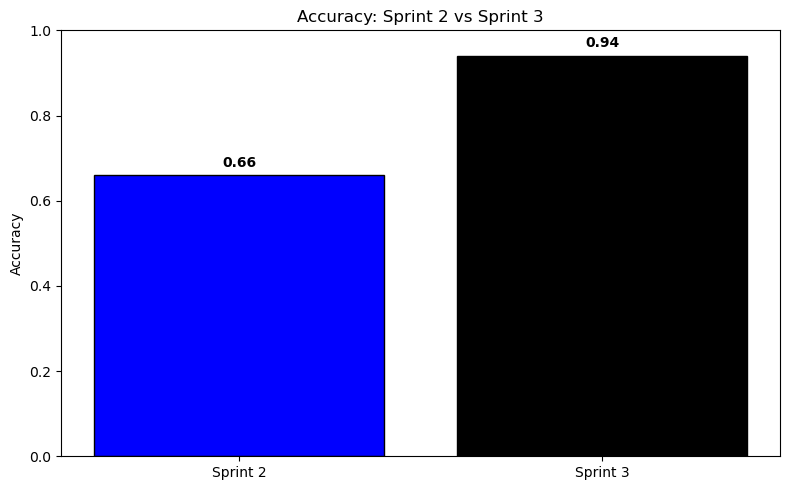

In [40]:
plt.figure(figsize=(8, 5))
plt.bar(['Sprint 2', 'Sprint 3'],
        [0.66, 0.94],
        color=['blue', 'black'], edgecolor='black')
plt.title('Accuracy: Sprint 2 vs Sprint 3')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate([0.66, 0.94]):
    plt.text(i, v + 0.02, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

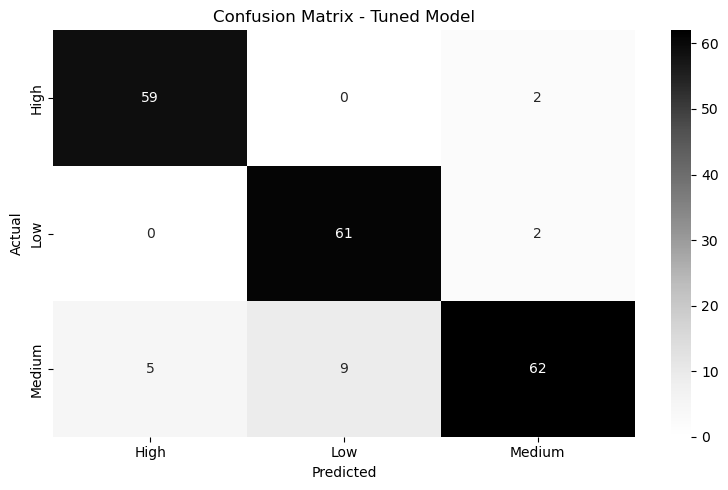

In [19]:
cm = confusion_matrix(y_test, best_predictions)
plt.figure(figsize=(8, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greys',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix - Tuned Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

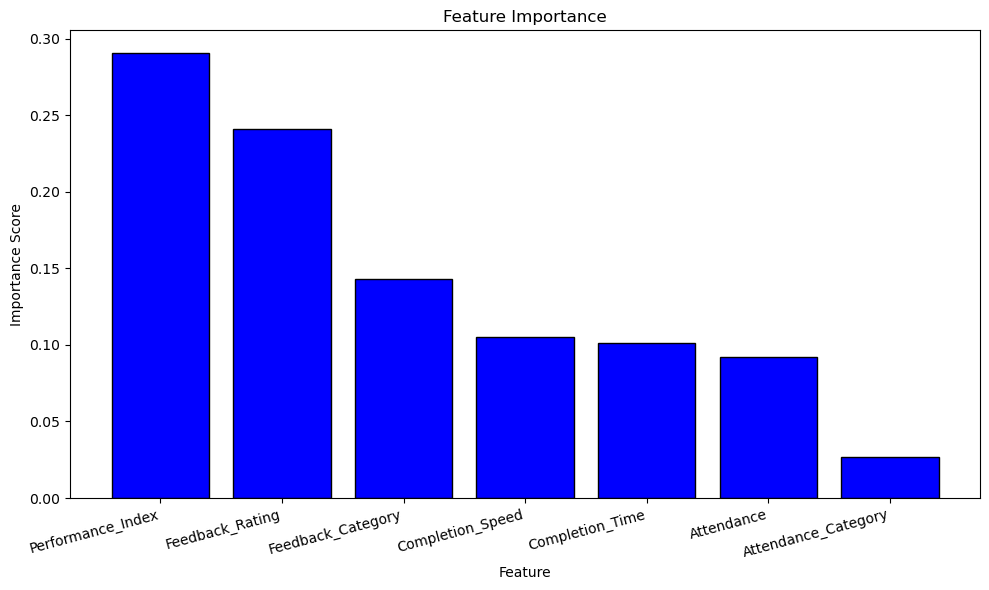

In [20]:
feature_importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature'],
        feature_importance['Importance'],
        color='blue', edgecolor='black')
plt.title('Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

In [31]:
comparison_df.to_csv('sprint3_comparison.csv', index=False)
print("Files saved!")

Files saved!
